# Deep clustering of rain-induced noise: spatial test
```
This test is repeat the workflow at two additional channels (Ch 60 and 1438) (*not included in this notebook*).
We use well-trained DEC models (trained with Ch 60 and 1438 data) and show the predictions on the same rain events (Aug 18, 2021)
```

**Figures:**

This notebook is used to plot Figures 13 in the manuscript.

In [1]:
import os

import numpy as np
import pandas as pd

import torch

from model_DEC import autoencoder, DEC_net
from DEC_utils import get_stft_freq, switch_label, fft_taper
from scipy import signal
from scipy.signal import medfilt

import obspy

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
import config as args
np.random.seed(0)
device = 'cuda' # Test is running on CPU with well-trained model
datadir = './data/'

In [3]:
from matplotlib.ticker import MultipleLocator,LogLocator,MaxNLocator, NullLocator
import matplotlib.gridspec as gridspec

font = {'size': 11}
plt.rc('font', **font)

# Functions

In [7]:
def preprocess_input(data):
    from sklearn.preprocessing import StandardScaler
    # standarize data
    data = np.log(data)
    nsamples = data.shape[0]

    X = np.reshape(data, (nsamples, 76*56))
    scaler = StandardScaler()
    # scaler = MinMaxScaler(feature_range=(-1, 1))
    X = scaler.fit_transform(X.T).T
    X = np.reshape(X, (nsamples, 76, 56))
    data0 = X
    return data0

In [17]:
def predict_from_model(model, data, reorder=[0,3,1,2], device='cpu'):
    '''
    model: DEC model
    data: DAS spectrogram data
    reorder: reorder the output label to let 0->3 represents weak->strong 
    '''
    # data_test = preprocess_input(data)
    data_test = data
    d_test = torch.from_numpy(data_test).to(device).to(torch.float32)
    
    y_pred, _, _ = model(d_test)
    y = y_pred.max(1)[1].detach().cpu().numpy()
    y_after = switch_label(y, reorder)
    return y_after

## 1. Load other resources for validation

## 1.1 Power Spectral Density (PSD) data

In [9]:
workdir = '/egg1/s2/jxs2475/codes/AE/DEC_DAS'

In [10]:
# The psd files contain data from 7 channels (# 60, 308, 1257, 1438, 1691, 1896, 1965) 

# 2019
psd_all1 = np.load(f'{workdir}/data/DAS_psd/psd_7ch_jun.npy')[:,0,:]
psd_all2 = np.load(f'{workdir}/data/DAS_psd/psd_7ch_jul.npy')[:,0,:]
psd_all3 = np.load(f'{workdir}/data/DAS_psd/psd_7ch_aug.npy')[:,0,:]
psd_21 = np.concatenate([psd_all1, psd_all2, psd_all3], axis=0)
# 2021
# psd_21 = np.load(datadir+'DAS_psd/Ch359_psd_0601_0930.npy')

In [11]:
# freq_psd: the frequency of psd data
from matplotlib import mlab
Fs = 250
divs_per_window = 13 
window_len = 60 # second
nfft = int(window_len / divs_per_window * Fs)
ovlp = 0.5
_, freq_psd = mlab.psd(np.ones(250*60), nfft, Fs, detrend=mlab.detrend_linear, window=fft_taper,
                          noverlap=int(ovlp * nfft), sides='onesided', scale_by_freq=True)

## 1.2 Rainfall rate data from the weather station

In [12]:
# 2021
df_21 = pd.read_csv(datadir+'/weather_data/rain_beaver_2021.csv',parse_dates=True,index_col=[1])
df_21 = df_21.resample('T').mean()
df_21.index = df_21.index + pd.DateOffset(hours=4)
df_21['Rain Rate'] = df_21['Rain Rate'].interpolate()

In [13]:
# Time window
t0_2021 = obspy.UTCDateTime('202106010000')
start = obspy.UTCDateTime('202108180000')
end = obspy.UTCDateTime('202108191200')

i1 = int((start-t0_2021)/60)
i2 = int((end-t0_2021)/60)

In [25]:
df_sub = df_21[df_21.index.isin(pd.date_range(start='2021-08-18 00:00',
                                    end='2021-08-19 12:00',freq='T'))]
rain = df_sub['Rain Rate'].values

# 2. Load DAS data (spectrograms)

In [15]:
data1 = np.load(f'{workdir}/data/DAS_spec/ch60_spec_359_jun21.npy')
data2 = np.load(f'{workdir}/data/DAS_spec/ch60_spec_359_jul21.npy')
data3 = np.load(f'{workdir}/data/DAS_spec/ch60_spec_359_aug21.npy')
data60 = np.concatenate((data1, data2, data3), axis=0)
data60_test = data60[i1:i2]
data60_test = preprocess_input(data60_test)

In [18]:
DEC = DEC_net(args).cuda()
DEC.load_state_dict(torch.load(f'{workdir}/results/model_weights/DEC_ch60', map_location=device, weights_only=True))

y_after = predict_from_model(DEC, data60_test, reorder=[3,0,1,2], device=device)
y_after_60_retrain= medfilt(y_after, kernel_size=3)

In [19]:
data1 = np.load(f'{workdir}/data/DAS_spec/ch1438_spec_359_jun21.npy')
data2 = np.load(f'{workdir}/data/DAS_spec/ch1438_spec_359_jul21.npy')
data3 = np.load(f'{workdir}/data/DAS_spec/ch1438_spec_359_aug21.npy')
data1438 = np.concatenate((data1, data2, data3), axis=0)
data1438_test = data1438[i1:i2]
data1438_test = preprocess_input(data1438_test)

In [20]:
DEC = DEC_net(args).cuda()
DEC.load_state_dict(torch.load(f'{workdir}/results/model_weights/DEC_ch1438', map_location=device, weights_only=True))

y_after = predict_from_model(DEC, data1438_test, reorder=[1,3,0,2], device=device)
y_after_1438_retrain= medfilt(y_after, kernel_size=3)

In [21]:
psd_all1 = np.load(f'{workdir}/data/DAS_psd/psd_7ch_jun.npy')
psd_all2 = np.load(f'{workdir}/data/DAS_psd/psd_7ch_jul.npy')
psd_all3 = np.load(f'{workdir}/data/DAS_psd/psd_7ch_aug.npy')
psd_all = np.concatenate([psd_all1, psd_all2, psd_all3], axis=0)

In [23]:
psd_60 = psd_all[:, 0, :]
psd_1438 = psd_all[:, 3, :]

psd_60_sub = psd_60[i1:i2]
psd_1438_sub = psd_1438[i1:i2]

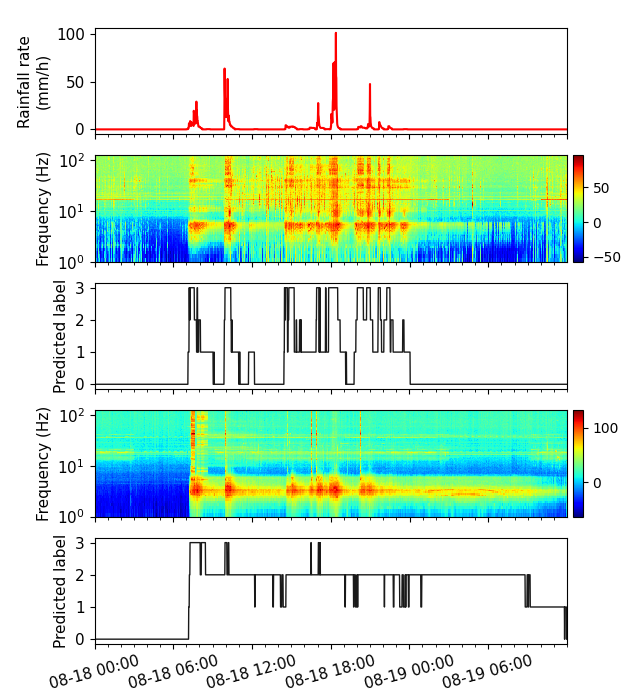

In [36]:
fig, axes = plt.subplots(ncols=1, nrows=5, figsize=(6.3,7))
fig.subplots_adjust(left=0.15, bottom=0.08, right=0.9, top=0.96, hspace=0.2)

axes[0].plot(rain*25.4, c='r')
axes[0].set_ylabel('Rainfall rate\n(mm/h)')
axes[0].set_xlim([0,rain.size])
axes[0].xaxis.set_major_locator(MultipleLocator(6*60))
axes[0].xaxis.set_minor_locator(MultipleLocator(60))
axes[0].set_xticklabels([])

im = axes[1].pcolormesh(np.arange(0,i2-i1), freq_psd+freq_psd[1]-freq_psd[0], 10*np.log(psd_1438_sub.T), cmap=plt.get_cmap('jet'), shading='auto')
axes[1].set_yscale('log')
axes[1].set_ylim([1,125])
axes[1].xaxis.set_major_locator(MultipleLocator(6*60))
axes[1].xaxis.set_minor_locator(MultipleLocator(60))
axes[1].yaxis.set_major_locator(LogLocator(base=10, numticks=30))
axes[1].yaxis.set_minor_locator(LogLocator(base=10, numticks=10))
axes[1].set_xticklabels([])
axes[1].set_ylabel('Frequency (Hz)')

label_dates = [x.strftime("%m-%d %H:%M") for x in 
               pd.date_range(start='2021-08-18 00:00',end='2021-08-19 11:00', freq='6H')]

axes[2].plot(range(y_after.shape[0]), y_after_1438_retrain, lw=1, c='k', alpha=0.9)
axes[2].xaxis.set(ticks=np.arange(0,y_after.shape[0],6*60),ticklabels=label_dates)
axes[2].set_xlim([0,rain.size])
axes[2].tick_params(axis='x', labelrotation = 15)
axes[2].xaxis.set_minor_locator(MultipleLocator(60))
axes[2].yaxis.set_major_locator(MultipleLocator(1))
axes[2].set_xticklabels([])
axes[2].set_ylabel('Predicted label')


im2 = axes[3].pcolormesh(np.arange(0,i2-i1), freq_psd+freq_psd[1]-freq_psd[0], 10*np.log(psd_60_sub.T), cmap=plt.get_cmap('jet'), shading='auto')
axes[3].set_yscale('log')
axes[3].set_ylim([1,125])
axes[3].xaxis.set_major_locator(MultipleLocator(6*60))
axes[3].xaxis.set_minor_locator(MultipleLocator(60))
axes[3].yaxis.set_major_locator(LogLocator(base=10, numticks=30))
axes[3].yaxis.set_minor_locator(LogLocator(base=10, numticks=10))
axes[3].set_xticklabels([])
axes[3].set_ylabel('Frequency (Hz)')

axes[4].plot(range(y_after.shape[0]), y_after_60_retrain, lw=1, c='k', alpha=0.9)
axes[4].xaxis.set(ticks=np.arange(0,y_after.shape[0],6*60),ticklabels=label_dates)
axes[4].set_xlim([0,rain.size])
axes[4].tick_params(axis='x', labelrotation = 15)
axes[4].xaxis.set_minor_locator(MultipleLocator(60))
axes[4].yaxis.set_major_locator(MultipleLocator(1))
axes[4].set_ylabel('Predicted label')

pos = axes[1].get_position()
cbar_ax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.015, pos.height])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cbar_ax.tick_params(labelsize=10)

pos = axes[3].get_position()
cbar_ax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.015, pos.height])  # [left, bottom, width, height]
fig.colorbar(im2, cax=cbar_ax, orientation='vertical')
cbar_ax.tick_params(labelsize=10)

#plt.savefig('fig13.png', dpi=300)